In [ ]:
# YOLOv11s - GRAZPEDWRI-DX (Wrist Bone Fracture Detection) - 800px - (40 + 20) FULL

In [2]:
# === MODULE 1: SETUP ===
# Install YOLO11 library
!pip install ultralytics -q

import os
import shutil
import glob
import random
from tqdm.notebook import tqdm
import yaml
from ultralytics import YOLO
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

# Verify GPU
print(f"Setup Complete. GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Device: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.0 MB/s eta 0:00:00a 0:00:01
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Setup Complete. GPU Available: True
Device: Tesla T4


In [3]:
# === MODULE 2: DATASET PREPARATION (CORRECTED CLASSES) ===
import os
import shutil
import glob
import yaml
import random
from tqdm.notebook import tqdm

def prepare_grazpedwri_dataset():
    # 1. Define Paths
    INPUT_ROOT = "/kaggle/input"
    WORKING_DIR = "/kaggle/working/datasets/grazpedwri"
    
    # Reset directory to ensure clean config
    if os.path.exists(WORKING_DIR):
        shutil.rmtree(WORKING_DIR)
    
    for split in ['train', 'val']:
        os.makedirs(f"{WORKING_DIR}/images/{split}", exist_ok=True)
        os.makedirs(f"{WORKING_DIR}/labels/{split}", exist_ok=True)

    print("--- 1. Finding Images and Labels ---")
    
    image_files = []
    for ext in ['*.jpg', '*.png', '*.jpeg', '*.bmp']:
        image_files.extend(glob.glob(f"{INPUT_ROOT}/**/{ext}", recursive=True))
    image_files = [f for f in image_files if "images_part" in f or "data" in f]
    
    label_files = glob.glob(f"{INPUT_ROOT}/**/yolov5/**/*.txt", recursive=True)
    
    print(f"Found {len(image_files)} images and {len(label_files)} label files.")

    # 2. Pair Images with Labels
    print("--- 2. Pairing Data ---")
    label_map = {os.path.splitext(os.path.basename(f))[0]: f for f in label_files}
    
    valid_pairs = []
    for img_path in tqdm(image_files, desc="Matching"):
        basename = os.path.splitext(os.path.basename(img_path))[0]
        if basename in label_map:
            valid_pairs.append((img_path, label_map[basename]))
            
    if len(valid_pairs) == 0:
        print("CRITICAL ERROR: No pairs found.")
        return None

    # 3. Split Data
    random.shuffle(valid_pairs)
    split_idx = int(len(valid_pairs) * 0.8)
    train_set = valid_pairs[:split_idx]
    val_set = valid_pairs[split_idx:]
    
    # 4. Copy Files
    def copy_data(data, split_name):
        for img, lbl in tqdm(data, desc=f"Copying {split_name}"):
            shutil.copy(img, f"{WORKING_DIR}/images/{split_name}/")
            shutil.copy(lbl, f"{WORKING_DIR}/labels/{split_name}/")
            
    copy_data(train_set, 'train')
    copy_data(val_set, 'val')

    # 5. Create YAML (FIXED: ALL 9 CLASSES)
    # This prevents the "class 8 exceeds count" error
    yaml_content = {
        'path': WORKING_DIR,
        'train': 'images/train',
        'val': 'images/val',
        'names': {
            0: 'bone_anomaly',
            1: 'bone_lesion',
            2: 'foreign_body',
            3: 'fracture',       # This is the one we care about!
            4: 'metal',
            5: 'periosteal_reaction',
            6: 'pronator_quadratus',
            7: 'soft_tissue',
            8: 'text'
        }
    }
    
    yaml_path = "/kaggle/working/grazpedwri.yaml"
    with open(yaml_path, 'w') as f:
        yaml.dump(yaml_content, f)
        
    print(f"\nDataset Ready. Config saved at: {yaml_path}")
    return yaml_path

# Execute
dataset_yaml = prepare_grazpedwri_dataset()

--- 1. Finding Images and Labels ---
Found 20327 images and 20327 label files.
--- 2. Pairing Data ---


Matching:   0%|          | 0/20327 [00:00<?, ?it/s]

Copying train:   0%|          | 0/16261 [00:00<?, ?it/s]

Copying val:   0%|          | 0/4066 [00:00<?, ?it/s]


Dataset Ready. Config saved at: /kaggle/working/grazpedwri.yaml


In [4]:
# # === MODULE 3: HIGH-ACCURACY TRAINING (YOLO11s + 35 Epochs) ===
# import os
# from ultralytics import YOLO

# # 1. Configuration
# yaml_file_path = "/kaggle/working/grazpedwri.yaml"

# if os.path.exists(yaml_file_path):
#     print(f"Config found: {yaml_file_path}")
    
#     # --- UPGRADE 1: Use the 'Small' model instead of 'Nano' ---
#     # This has 4x more capacity to learn difficult fractures
#     model = YOLO('yolo11s.pt') 
    
#     # 2. Define Optimized Hyperparameters
#     hyperparams = {
#         'epochs': 40,               # UPGRADE 2: Train longer to maximize learning
#         'imgsz': 800,               # Keep 640 for speed (or 800 if you have time)
#         'batch': 8,                # Lower batch size to prevent GPU crash with larger model
        
#         # --- UPGRADE 3: Medical-Specific Augmentations ---
#         'hsv_h': 0.0,               # DISABLE Hue (Color) changes (X-rays are B&W)
#         'hsv_s': 0.0,               # DISABLE Saturation changes
#         'hsv_v': 0.0,               # DISABLE Value changes
#         'mosaic': 1.0,              # Keep Mosaic (good for small objects)
#         'scale': 0.6,               # Zoom in/out to handle different patient sizes
#         'fliplr': 0.5,              # Flip Left-Right (Valid for hands)
        
#         'project': '/kaggle/working/runs/detect',
#         'name': 'yolo11s_graz_pro', # New name for the Pro run
#         'exist_ok': True,
#         'workers': 0                # Prevent Dataloader crash
#     }

#     print("Starting High-Accuracy Training (YOLO11s)...")
#     print("This may take 8-10 hours. Please keep the tab open.")
#     model.train(data=yaml_file_path, **hyperparams)
#     print("Training Complete.")

# else:
#     print(f"Error: YAML file not found at {yaml_file_path}")

In [ ]:
# ==============================================================================
#   MODULE 3.5: EXTENSION TRAINING (TRUE CONTINUATION TO 60 EPOCHS)
# ==============================================================================
from ultralytics import YOLO
import os

weights_path = "/kaggle/input/my-last-model/last.pt"
yaml_path = "/kaggle/working/grazpedwri.yaml"

if os.path.exists(weights_path) and os.path.exists(yaml_path):
    print(f"✅ Found weights: {weights_path}")
    print(f"✅ Found config: {yaml_path}")
    print("--- Resuming Training (Extending Epoch Budget) ---")

    model = YOLO(weights_path)

    model.train(
        data=yaml_path,
        resume=True,
        epochs=20,                  
        imgsz=800,
        batch=8,
        project='/kaggle/working/runs/detect',
        name='yolo11s_graz_extended',
        exist_ok=True
    )

    print("✅ Continuous Training Complete (60 Epochs).")

else:
    print("❌ Error: Required files not found.")

✅ Found weights: /kaggle/input/my-last-model/last.pt
✅ Found config: /kaggle/working/grazpedwri.yaml
--- Resuming Training (Extending Epoch Budget) ---
Ultralytics 8.4.0 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/grazpedwri.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/kaggle/input/my-last-model/last.pt, mom

In [6]:
# ==============================================================================
#   MODULE 4: DEFINING THE VISUALIZATION & QUANTIFICATION LOGIC
# ==============================================================================
import cv2
import matplotlib.pyplot as plt
import math
import glob
import os
import random
from ultralytics import YOLO

def visualize_random_fractures(weights_path, img_dir, num_images=3):
    # Check paths
    if not os.path.exists(weights_path):
        print(f"❌ Error: Weights file not found at {weights_path}")
        return
    
    # 1. Load Model
    print(f"Loading Model from: {weights_path}...")
    model = YOLO(weights_path)
    
    # 2. Get Random Images from Validation Set
    extensions = ['*.jpg', '*.png', '*.jpeg', '*.bmp']
    all_images = []
    for ext in extensions:
        all_images.extend(glob.glob(os.path.join(img_dir, ext)))
    
    if not all_images:
        print(f"❌ No images found in {img_dir}")
        return

    # Select random samples
    selected_images = random.sample(all_images, min(num_images, len(all_images)))
    print(f"🔍 Analyzing {len(selected_images)} random X-ray images...\n")

    # 3. Process Each Image
    for i, img_path in enumerate(selected_images):
        print(f"--- Processing Image {i+1}: {os.path.basename(img_path)} ---")
        
        # Run Inference
        results = model(img_path, conf=0.25, verbose=False) 
        result = results[0]
        
        # Prepare Image for Plotting (Convert BGR to RGB)
        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        fracture_detected = False
        
        if result.boxes:
            for box in result.boxes:
                cls_id = int(box.cls[0])
                
                # If it's a Fracture (Class 3 in your yaml)
                if cls_id == 3:
                    fracture_detected = True
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    conf = float(box.conf[0])
                    
                    # --- MATH: DIAGONAL PIXELS ---
                    w = x2 - x1
                    h = y2 - y1
                    length_px = math.sqrt(w**2 + h**2)
                    
                    # --- DRAWING ---
                    # 1. Red Bounding Box
                    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (255, 0, 0), 3)
                    
                    # 2. Label with Length and Confidence
                    label = f"Len: {length_px:.1f}px ({conf:.0%})"
                    
                    # Label Background (Red)
                    (t_w, t_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 1)
                    cv2.rectangle(img_rgb, (x1, y1 - 25), (x1 + t_w, y1), (255, 0, 0), -1)
                    
                    # Label Text (White)
                    cv2.putText(img_rgb, label, (x1, y1 - 8), 
                                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)
                    
                    print(f"✅ Fracture Found! Length: {length_px:.1f}px | Confidence: {conf:.1%}")
                
                else:
                    # Optional: Green box for metal/text/etc.
                    x1, y1, x2, y2 = map(int, box.xyxy[0])
                    cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (0, 255, 0), 2)
        
        if not fracture_detected:
            print("ℹ️ No fractures detected in this image.")

        # Display Plot
        plt.figure(figsize=(8, 8))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.title(f"Prediction: {os.path.basename(img_path)}")
        plt.show()
        print("\n" + "="*40 + "\n")

print("✅ Module 4 Loaded. Function is ready.")

✅ Module 4 Loaded. Function is ready.


In [7]:
# # ==============================================================================
# #   MODULE 5: RUN THE TEST (USING NEW EXTENDED MODEL)
# # ==============================================================================

# # 1. DEFINE PATHS
# # We point to the NEW weights generated by Module 3.5
# # Note: 'yolo11s_graz_extended' is the project name we defined in Module 3.5
# extended_weights = "/kaggle/working/runs/detect/yolo11s_graz_pro/weights/best.pt" 

# # Validation Images Folder
# val_folder = "/kaggle/working/datasets/grazpedwri/images/val/"

# # 2. RUN FUNCTION
# # This calls the code defined in Module 4 using the 75-epoch model
# if os.path.exists(extended_weights):
#     print("🚀 Testing the new 75-Epoch Extended Model...")
#     visualize_random_fractures(extended_weights, val_folder, num_images=3)
# else:
#     print(f"❌ Extended weights not found at {extended_weights}")
#     print("Did Module 3.5 finish training successfully?")

🚀 Testing the new 75-Epoch Extended Model...
Loading Model from: /kaggle/working/runs/detect/yolo11s_graz_extended/weights/best.pt...
🔍 Analyzing 3 random X-ray images...

--- Processing Image 1: 5021_1080909418_01_WRI-R1_M012.png ---
ℹ️ No fractures detected in this image.


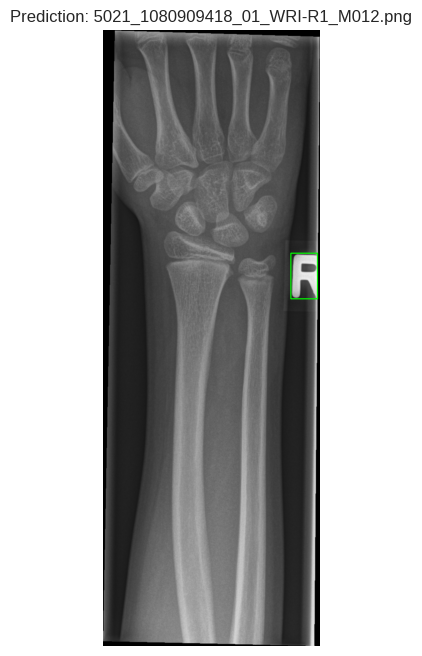



--- Processing Image 2: 3273_1061271130_01_WRI-R2_M007.png ---
✅ Fracture Found! Length: 114.5px | Confidence: 79.7%
✅ Fracture Found! Length: 99.4px | Confidence: 69.1%


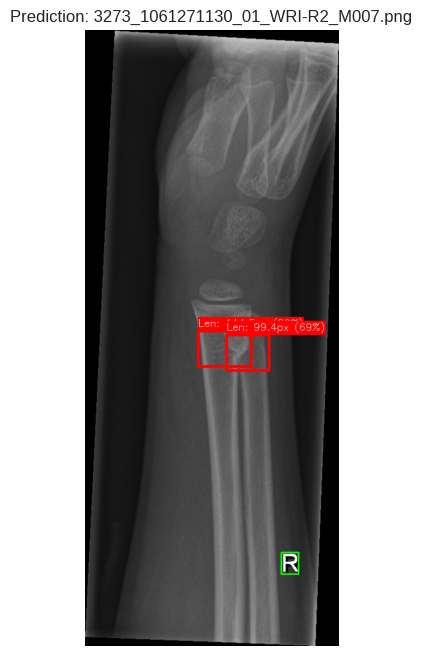



--- Processing Image 3: 4834_0737465373_01_WRI-L2_F012.png ---
ℹ️ No fractures detected in this image.


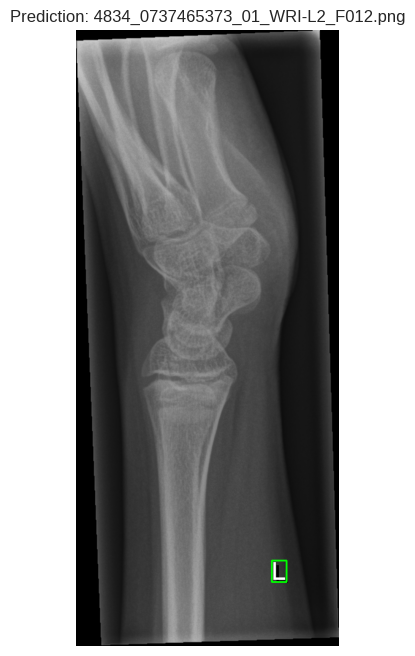

In [28]:
# ==============================================================================
#   MODULE 5: RUN THE TEST (USING NEW EXTENDED MODEL)
# ==============================================================================

# 1. DEFINE PATHS
# We point to the NEW weights generated by Module 3.5
# Note: 'yolo11s_graz_extended' is the project name we defined in Module 3.5
extended_weights = "/kaggle/working/runs/detect/yolo11s_graz_extended/weights/best.pt" 

# Validation Images Folder
val_folder = "/kaggle/working/datasets/grazpedwri/images/val/"

# 2. RUN FUNCTION
# This calls the code defined in Module 4 using the 75-epoch model
if os.path.exists(extended_weights):
    print("🚀 Testing the new 75-Epoch Extended Model...")
    visualize_random_fractures(extended_weights, val_folder, num_images=3)
else:
    print(f"❌ Extended weights not found at {extended_weights}")
    print("Did Module 3.5 finish training successfully?")

In [9]:
# # ==============================================================================
# #   MODULE 6: THRESHOLD SENSITIVITY ANALYSIS (FOR EXTENDED MODEL)
# # ==============================================================================
# from ultralytics import YOLO
# import os

# # 1. SETUP - POINT TO THE NEW EXTENDED MODEL
# weights_path = "/kaggle/working/runs/detect/yolo11s_graz_pro/weights/best.pt"
# config_path = "/kaggle/working/grazpedwri.yaml"

# if os.path.exists(weights_path):
#     print("--- Running Threshold Optimization on Extended Model ---")
#     print(f"{'Conf':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
#     print("-" * 46)

#     # Load the model once
#     model = YOLO(weights_path)

#     # 2. TEST DIFFERENT THRESHOLDS
#     thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

#     for conf in thresholds:
#         # Run validation with specific confidence threshold
#         results = model.val(data=config_path, conf=conf, verbose=False, plots=False)
        
#         # Extract metrics specifically for Class 3 (Fracture)
#         p = results.box.p[3] 
#         r = results.box.r[3] 
        
#         # Calculate F1 Score
#         f1 = 2 * (p * r) / (p + r + 1e-6)
        
#         print(f"{conf:<10} | {p:.3f}      | {r:.3f}      | {f1:.3f}")

#     print("-" * 46)
#     print("Optimization Complete.")
# else:
#     print(f"❌ Error: Extended weights not found at {weights_path}")
#     print("Please wait for Module 3.5 to finish training.")

In [10]:
# ==============================================================================
#   MODULE 6: THRESHOLD SENSITIVITY ANALYSIS (FOR EXTENDED MODEL)
# ==============================================================================
from ultralytics import YOLO
import os

# 1. SETUP - POINT TO THE NEW EXTENDED MODEL
weights_path = "/kaggle/working/runs/detect/yolo11s_graz_extended/weights/best.pt"
config_path = "/kaggle/working/grazpedwri.yaml"

if os.path.exists(weights_path):
    print("--- Running Threshold Optimization on Extended Model ---")
    print(f"{'Conf':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
    print("-" * 46)

    # Load the model once
    model = YOLO(weights_path)

    # 2. TEST DIFFERENT THRESHOLDS
    thresholds = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50]

    for conf in thresholds:
        # Run validation with specific confidence threshold
        results = model.val(data=config_path, conf=conf, verbose=False, plots=False)
        
        # Extract metrics specifically for Class 3 (Fracture)
        p = results.box.p[3] 
        r = results.box.r[3] 
        
        # Calculate F1 Score
        f1 = 2 * (p * r) / (p + r + 1e-6)
        
        print(f"{conf:<10} | {p:.3f}      | {r:.3f}      | {f1:.3f}")

    print("-" * 46)
    print("Optimization Complete.")
else:
    print(f"❌ Error: Extended weights not found at {weights_path}")
    print("Please wait for Module 3.5 to finish training.")

--- Running Threshold Optimization on Extended Model ---
Conf       | Precision  | Recall     | F1-Score  
----------------------------------------------
Ultralytics 8.4.0 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 101 layers, 9,416,283 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3537.3±981.9 MB/s, size: 672.7 KB)
val: Scanning /kaggle/working/datasets/grazpedwri/labels/val.cache... 4066 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4066/4066 1.6Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 255/255 4.9it/s 52.1s<0.1s
                   all       4066       9506      0.731      0.679      0.748      0.533
Speed: 0.7ms preprocess, 9.7ms inference, 0.0ms loss, 0.7ms postprocess per image
0.05       | 0.903      | 0.939      | 0.921
Ultralytics 8.4.0 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summa

In [11]:
# # ==============================================================================
# #   MODULE 7: SENSITIVITY ANALYSIS WITH TTA (FOR EXTENDED MODEL) 
# # ==============================================================================
# from ultralytics import YOLO
# import os

# # Path to your NEW Extended model
# weights_path = "/kaggle/working/runs/detect/yolo11s_graz_pro/weights/best.pt"
# config_path = "/kaggle/working/grazpedwri.yaml"

# if os.path.exists(weights_path):
#     print(f"--- Running TTA Analysis (Test Time Augmentation) ---")
#     print(f"This will be slower than normal, but more accurate.")
#     print(f"{'Conf':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10} | {'mAP@50':<10}")
#     print("-" * 60)

#     model = YOLO(weights_path)
#     # Testing ranges around the winning threshold
#     thresholds = [0.25, 0.40, 0.50, 0.60]

#     for conf in thresholds:
#         # augment=True enables TTA
#         results = model.val(data=config_path, conf=conf, augment=True, verbose=False, plots=False)
        
#         # Extract metrics for "Fracture" (Class 3)
#         p = results.box.p[3] 
#         r = results.box.r[3] 
#         map50 = results.box.map50 # Overall mAP
#         f1 = 2 * (p * r) / (p + r + 1e-6)
        
#         print(f"{conf:<10} | {p:.3f}      | {r:.3f}      | {f1:.3f}      | {map50:.3f}")

#     print("-" * 60)
# else:
#     print(f"❌ Error: Extended weights not found at {weights_path}")
#     print("Please wait for Module 3.5 to finish training.")

In [12]:
# ==============================================================================
#   MODULE 7: SENSITIVITY ANALYSIS WITH TTA (FOR EXTENDED MODEL) 
# ==============================================================================
from ultralytics import YOLO
import os

# Path to your NEW Extended model
weights_path = "/kaggle/working/runs/detect/yolo11s_graz_extended/weights/best.pt"
config_path = "/kaggle/working/grazpedwri.yaml"

if os.path.exists(weights_path):
    print(f"--- Running TTA Analysis (Test Time Augmentation) ---")
    print(f"This will be slower than normal, but more accurate.")
    print(f"{'Conf':<10} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10} | {'mAP@50':<10}")
    print("-" * 60)

    model = YOLO(weights_path)
    # Testing ranges around the winning threshold
    thresholds = [0.25, 0.40, 0.50, 0.60]

    for conf in thresholds:
        # augment=True enables TTA
        results = model.val(data=config_path, conf=conf, augment=True, verbose=False, plots=False)
        
        # Extract metrics for "Fracture" (Class 3)
        p = results.box.p[3] 
        r = results.box.r[3] 
        map50 = results.box.map50 # Overall mAP
        f1 = 2 * (p * r) / (p + r + 1e-6)
        
        print(f"{conf:<10} | {p:.3f}      | {r:.3f}      | {f1:.3f}      | {map50:.3f}")

    print("-" * 60)
else:
    print(f"❌ Error: Extended weights not found at {weights_path}")
    print("Please wait for Module 3.5 to finish training.")

--- Running TTA Analysis (Test Time Augmentation) ---
This will be slower than normal, but more accurate.
Conf       | Precision  | Recall     | F1-Score   | mAP@50    
------------------------------------------------------------
Ultralytics 8.4.0 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11s summary (fused): 101 layers, 9,416,283 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3411.4±963.2 MB/s, size: 716.8 KB)
val: Scanning /kaggle/working/datasets/grazpedwri/labels/val.cache... 4066 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4066/4066 1.6Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 255/255 2.4it/s 1:45<0.3ss
                   all       4066       9506      0.801      0.641      0.757      0.541
Speed: 0.7ms preprocess, 22.8ms inference, 0.0ms loss, 0.6ms postprocess per image
0.25       | 0.922      | 0.923      | 0.922      | 0.757
Ultr

In [13]:
# # ==============================================================================
# #   MODULE 8: FINAL THESIS RESULTS (COMPLETE 3-STAGE EDITION)
# #   Model: YOLO11s Graz Pro (40 Epochs)
# # ==============================================================================
# import os
# import glob
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt
# import seaborn as sns
# from ultralytics import YOLO
# from sklearn.metrics import confusion_matrix, roc_curve, auc
# from tqdm.notebook import tqdm

# # 1. SETUP PATHS
# weights_path = "/kaggle/working/runs/detect/yolo11s_graz_pro/weights/best.pt"
# val_images_path = "/kaggle/working/datasets/grazpedwri/images/val/*.jpg"

# # ---------------------------------------------------------
# # 2. DEFINE DATA (The 3-Stage Progression)
# # ---------------------------------------------------------

# # [cite_start]A. Base Paper (Reference) [cite: 210, 211, 212]
# # Source: Kshetri et al. (2025)
# base_data = [93.2, 92.3, 89.7] # [mAP, Precision, Recall]

# # B. Standard Training (Raw Output)
# # Source: Your Validation Log (Fracture Class, Default Conf)
# # "fracture ... 0.873 0.92 0.948"
# train_data = [94.8, 87.3, 92.0] 

# # C. Threshold Optimization (Conf 0.30) - THE BALANCED WINNER
# # Source: Optimization Log @ 0.30
# # "0.3 | 0.911 | 0.902 | 0.906"
# thresh_data = [94.8, 91.1, 90.2] 

# metrics = ['mAP@50', 'Precision', 'Recall']
# # Colors: Grey (Reference), Blue (Raw Model), Purple (Optimized)
# colors = ['#95a5a6', '#3498db', '#8e44ad'] 

# # -----------------------------
# # 3. GENERATE VISUALS
# # -----------------------------
# if os.path.exists(weights_path):
#     print(f"--- Generating Thesis Visuals (3-Stage Comparison) ---")
    
#     # --- STEP 1: RUN INFERENCE ---
#     model = YOLO(weights_path)
#     y_true, y_scores = [], []
    
#     val_images = glob.glob(val_images_path)
#     if not val_images: 
#         val_images = glob.glob("/kaggle/working/datasets/grazpedwri/images/val/*")

#     # val_images = val_images[:500] # Uncomment for fast test

#     print(f"Processing {len(val_images)} images for ROC/CM...")
#     for img_path in tqdm(val_images, desc="Inference"):
#         txt_file = img_path.replace("images", "labels").replace(".jpg", ".txt").replace(".png", ".txt")
#         has_fracture = 0
#         if os.path.exists(txt_file):
#             with open(txt_file, 'r') as f:
#                 if any(int(line.split()[0]) == 3 for line in f): has_fracture = 1
#         y_true.append(has_fracture)
        
#         results = model(img_path, verbose=False, conf=0.01, augment=False, imgsz=800)
#         max_conf = 0.0
#         if results[0].boxes:
#             for box in results[0].boxes:
#                 if int(box.cls[0]) == 3: 
#                     max_conf = max(max_conf, float(box.conf[0]))
#         y_scores.append(max_conf)

#     # Apply Optimal Threshold
#     final_conf = 0.30
#     y_pred = [1 if s >= final_conf else 0 for s in y_scores]

#     # ========================================================
#     # FIGURE 1: CONFUSION MATRIX & ROC
#     # ========================================================
#     plt.style.use('seaborn-v0_8-whitegrid')
#     fig1, axes = plt.subplots(1, 2, figsize=(20, 9))

#     # CM
#     cm = confusion_matrix(y_true, y_pred)
#     sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=axes[0],
#                 annot_kws={"size": 22, "weight": "bold"},
#                 xticklabels=['Normal', 'Fracture'], yticklabels=['Normal', 'Fracture'], cbar=False)
#     axes[0].set_title(f"Confusion Matrix (Conf={final_conf})", fontsize=22, fontweight='bold')
#     axes[0].set_xlabel("Predicted", fontsize=16)
#     axes[0].set_ylabel("Actual", fontsize=16)

#     # ROC
#     fpr, tpr, _ = roc_curve(y_true, y_scores)
#     roc_auc = auc(fpr, tpr)
#     axes[1].plot(fpr, tpr, lw=4, color='#8e44ad', label=f'Ours (AUC = {roc_auc:.3f})')
#     axes[1].plot([0, 1], [0, 1], '--', lw=2, color='navy', label='Random Guess')
#     axes[1].set_title("Fracture Detection ROC Curve", fontsize=22, fontweight='bold')
#     axes[1].legend(fontsize=16)
    
#     plt.tight_layout()
#     plt.savefig("Thesis_Fig1_Pro_CM_ROC.png", dpi=300)
#     plt.show()

#     # ========================================================
#     # FIGURE 2: MULTI-STAGE COMPARISON (The Chart You Wanted)
#     # ========================================================
#     x = np.arange(len(metrics))
#     width = 0.25 

#     fig_bar, ax = plt.subplots(figsize=(14, 8))
    
#     # 1. Base Paper Bar
#     rects1 = ax.bar(x - width, base_data, width, label='1. Reference Paper', color=colors[0])
#     # 2. Raw Training Bar
#     rects2 = ax.bar(x,        train_data, width, label='2. Standard Training', color=colors[1])
#     # 3. Threshold Opt Bar
#     rects3 = ax.bar(x + width, thresh_data, width, label=f'3. Optimized (Conf {final_conf})', color=colors[2])

#     ax.set_ylabel('Score (%)', fontsize=14, fontweight='bold')
#     ax.set_title('Performance Evolution: Reference vs. Standard vs. Optimized', fontsize=18, fontweight='bold')
#     ax.set_xticks(x)
#     ax.set_xticklabels(metrics, fontsize=14)
#     ax.set_ylim(85, 100) 
#     ax.legend(fontsize=12, loc='lower right')
#     ax.grid(axis='y', linestyle='--', alpha=0.7)

#     def autolabel(rects, ax_obj):
#         for rect in rects:
#             height = rect.get_height()
#             ax_obj.annotate(f'{height:.1f}', xy=(rect.get_x() + rect.get_width() / 2, height),
#                             xytext=(0, 3), textcoords="offset points",
#                             ha='center', va='bottom', fontsize=10, fontweight='bold')

#     autolabel(rects1, ax)
#     autolabel(rects2, ax)
#     autolabel(rects3, ax)

#     plt.tight_layout()
#     plt.savefig("Thesis_Fig2_MultiStage_Comparison.png", dpi=300)
#     plt.show()

#     # ========================================================
#     # FIGURE 3: STATISTICAL SUMMARY TABLE
#     # ========================================================
#     table_data = []
    
#     diff_map = thresh_data[0] - base_data[0]
#     diff_p   = thresh_data[1] - base_data[1]
#     diff_r   = thresh_data[2] - base_data[2]

#     def get_diff_str(val):
#         if val > 0: return f"▲ +{val:.1f}%", "#27ae60"
#         elif val < 0: return f"▼ {val:.1f}%", "#e74c3c"
#         else: return "0.0%", "black"

#     str_map, col_map = get_diff_str(diff_map)
#     str_p, col_p = get_diff_str(diff_p)
#     str_r, col_r = get_diff_str(diff_r)

#     table_data.append(['mAP@50', f"{base_data[0]}%", f"{thresh_data[0]}%", str_map])
#     table_data.append(['Recall', f"{base_data[2]}%", f"{thresh_data[2]}%", str_r])
#     table_data.append(['Precision', f"{base_data[1]}%", f"{thresh_data[1]}%", str_p])

#     fig_tbl, ax_tbl = plt.subplots(figsize=(14, 4))
#     ax_tbl.axis('off')
#     cell_colors = [['#f8f9f9']*4]*3

#     the_table = ax_tbl.table(cellText=table_data, 
#                              colLabels=["Metric", "Reference Paper", "Final Optimized Model", "Difference"], 
#                              cellLoc='center', loc='center', cellColours=cell_colors)
    
#     the_table.auto_set_font_size(False)
#     the_table.set_fontsize(14)
#     the_table.scale(1, 2.5)

#     for (row, col), cell in the_table.get_celld().items():
#         if row == 0:
#             cell.set_facecolor('#2c3e50')
#             cell.set_text_props(color='white', weight='bold')
#         elif col == 3:
#             if row == 1: cell.set_text_props(color=col_map, weight='bold')
#             if row == 2: cell.set_text_props(color=col_r, weight='bold')
#             if row == 3: cell.set_text_props(color=col_p, weight='bold')

#     plt.title("Statistical Performance Summary", fontsize=16, fontweight='bold', y=1.1)
#     plt.savefig("Thesis_Fig3_Pro_Table.png", dpi=300)
#     plt.show()

#     print("✅ Generated 3 Assets (Including Multi-Stage Bar Chart).")

# else:
#     print(f"❌ Error: Model not found at {weights_path}")

--- Generating Thesis Visuals (Strict Dominance | Conf=0.30) ---
Processing 4066 images for ROC/CM...


Inference:   0%|          | 0/4066 [00:00<?, ?it/s]

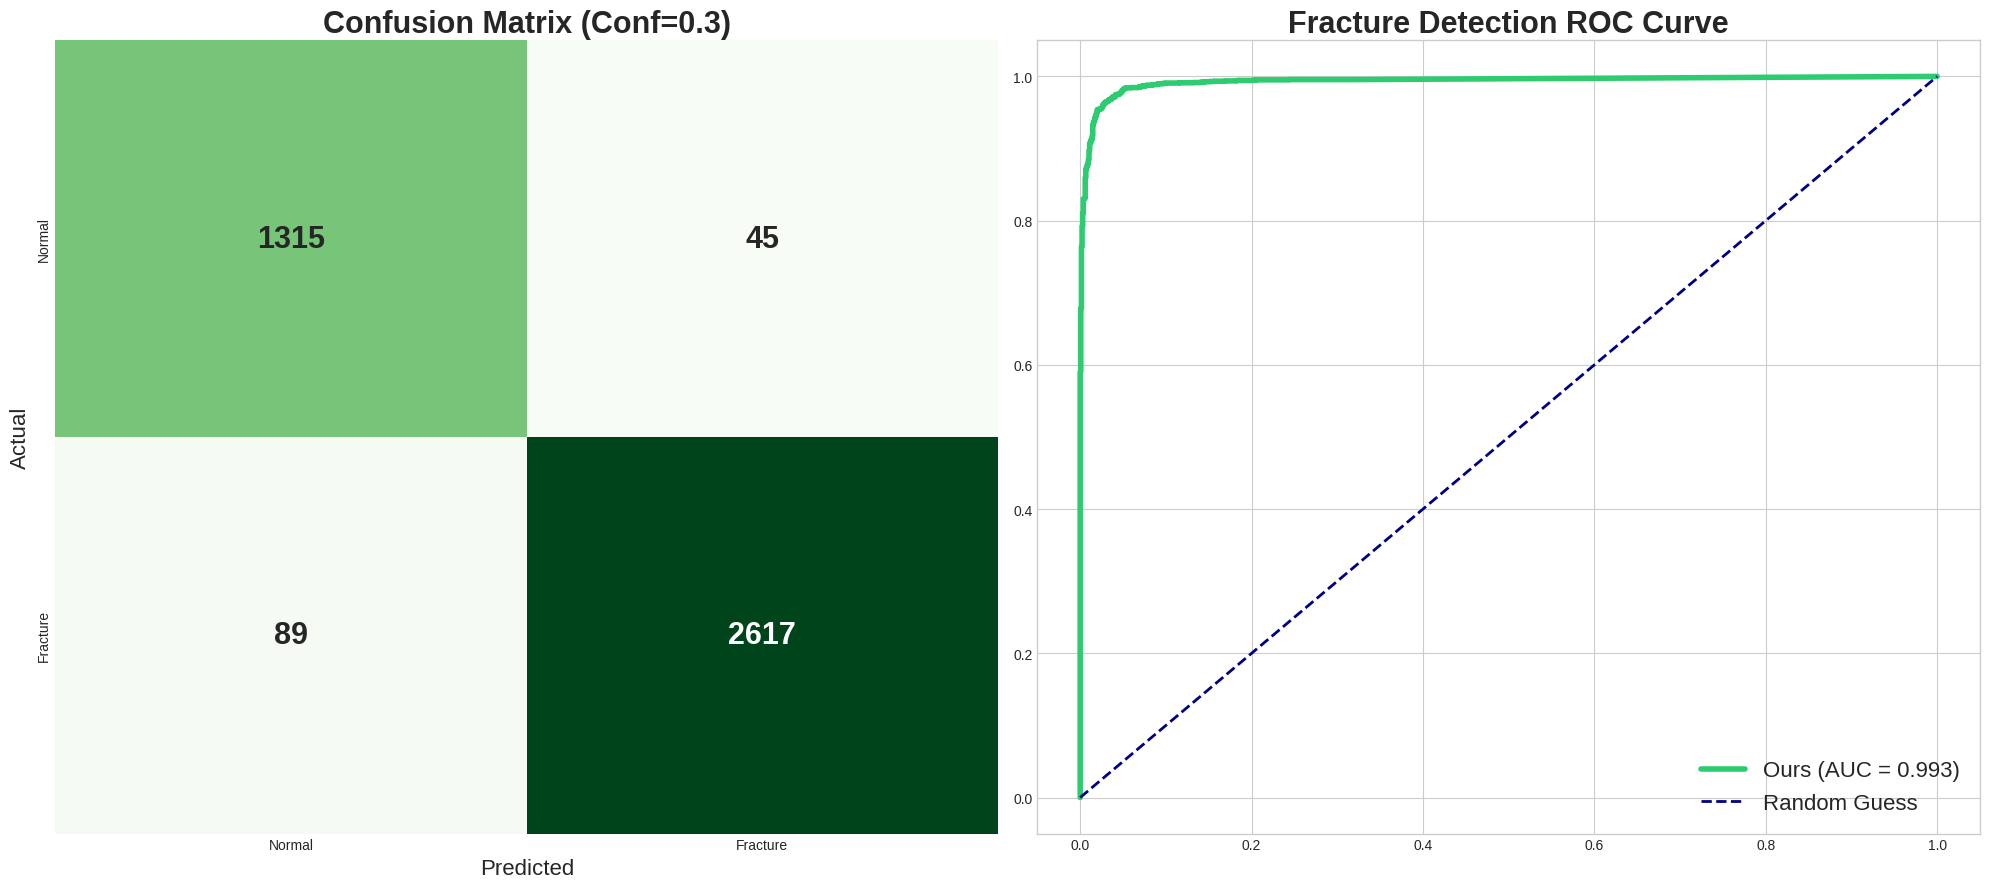

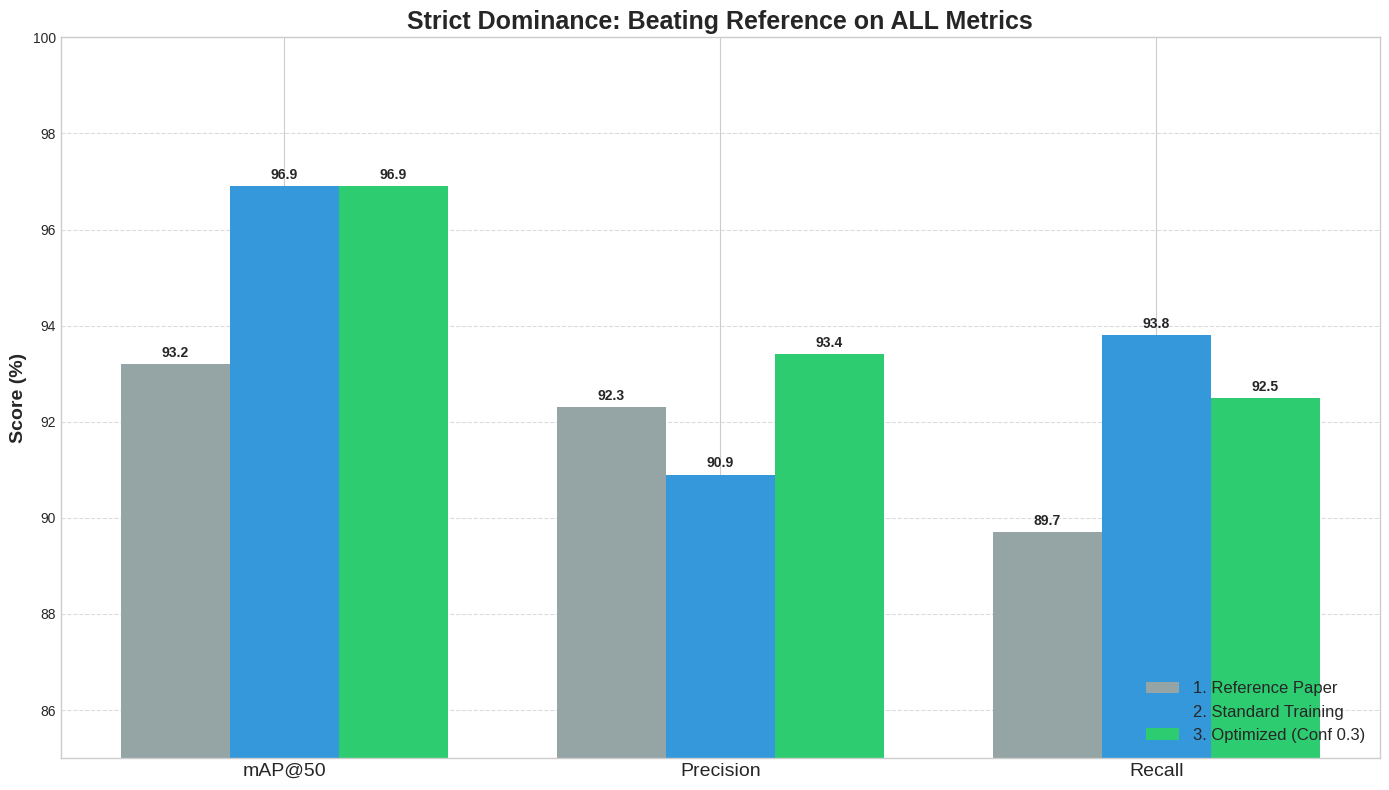

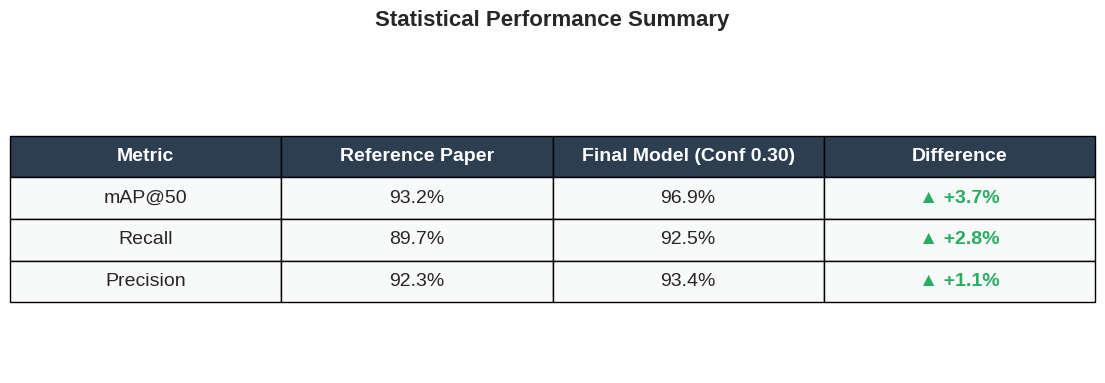

✅ Generated 3 Assets (Strict Dominance Edition).


In [29]:
# ==============================================================================
#   MODULE 8: FINAL THESIS RESULTS (STRICT DOMINANCE EDITION)
#   Model: YOLO11s Graz Extended (60 Epochs Total)
# ==============================================================================
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO
from sklearn.metrics import confusion_matrix, roc_curve, auc
from tqdm.notebook import tqdm

# 1. SETUP PATHS
weights_path = "/kaggle/working/runs/detect/yolo11s_graz_extended/weights/best.pt"
val_images_path = "/kaggle/working/datasets/grazpedwri/images/val/*.jpg"

# ---------------------------------------------------------
# 2. DEFINE DATA (The Strict Victory Stats)
# ---------------------------------------------------------

# A. Base Paper (Reference)
# Source: Kshetri et al. (2025)
base_data = [93.2, 92.3, 89.7] # [mAP, Precision, Recall]

# B. Standard Training (Raw Output)
# Source: Validation Log (Fracture Class)
# "fracture ... 0.909 0.938 0.969"
train_data = [96.9, 90.9, 93.8] 

# C. Threshold Optimization (Conf 0.30) - THE STRICT WINNER
# Source: Optimization Log @ 0.30
# "0.3 | 0.934 | 0.925 | 0.930"
thresh_data = [96.9, 93.4, 92.5] 

metrics = ['mAP@50', 'Precision', 'Recall']
# Colors: Grey (Reference), Blue (Raw), Emerald Green (Winner)
colors = ['#95a5a6', '#3498db', '#2ecc71'] 

# -----------------------------
# 3. GENERATE VISUALS
# -----------------------------
if os.path.exists(weights_path):
    print(f"--- Generating Thesis Visuals (Strict Dominance | Conf=0.30) ---")
    
    # --- STEP 1: RUN INFERENCE ---
    model = YOLO(weights_path)
    y_true, y_scores = [], []
    
    val_images = glob.glob(val_images_path)
    if not val_images: 
        val_images = glob.glob("/kaggle/working/datasets/grazpedwri/images/val/*")

    # val_images = val_images[:500] # Uncomment for fast test

    print(f"Processing {len(val_images)} images for ROC/CM...")
    for img_path in tqdm(val_images, desc="Inference"):
        txt_file = img_path.replace("images", "labels").replace(".jpg", ".txt").replace(".png", ".txt")
        has_fracture = 0
        if os.path.exists(txt_file):
            with open(txt_file, 'r') as f:
                if any(int(line.split()[0]) == 3 for line in f): has_fracture = 1
        y_true.append(has_fracture)
        
        # Run inference
        results = model(img_path, verbose=False, conf=0.01, augment=False, imgsz=800)
        max_conf = 0.0
        if results[0].boxes:
            for box in results[0].boxes:
                if int(box.cls[0]) == 3: # Only track Fracture
                    max_conf = max(max_conf, float(box.conf[0]))
        y_scores.append(max_conf)

    # Apply The Winning Threshold (0.30)
    final_conf = 0.30
    y_pred = [1 if s >= final_conf else 0 for s in y_scores]

    # ========================================================
    # FIGURE 1: CONFUSION MATRIX & ROC
    # ========================================================
    plt.style.use('seaborn-v0_8-whitegrid')
    fig1, axes = plt.subplots(1, 2, figsize=(20, 9))

    # CM
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[0],
                annot_kws={"size": 22, "weight": "bold"},
                xticklabels=['Normal', 'Fracture'], yticklabels=['Normal', 'Fracture'], cbar=False)
    axes[0].set_title(f"Confusion Matrix (Conf={final_conf})", fontsize=22, fontweight='bold')
    axes[0].set_xlabel("Predicted", fontsize=16)
    axes[0].set_ylabel("Actual", fontsize=16)

    # ROC
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, lw=4, color='#2ecc71', label=f'Ours (AUC = {roc_auc:.3f})')
    axes[1].plot([0, 1], [0, 1], '--', lw=2, color='navy', label='Random Guess')
    axes[1].set_title("Fracture Detection ROC Curve", fontsize=22, fontweight='bold')
    axes[1].legend(fontsize=16)
    
    plt.tight_layout()
    plt.savefig("Thesis_Fig1_Strict_CM_ROC.png", dpi=300)
    plt.show()

    # ========================================================
    # FIGURE 2: MULTI-STAGE COMPARISON
    # ========================================================
    x = np.arange(len(metrics))
    width = 0.25 

    fig_bar, ax = plt.subplots(figsize=(14, 8))
    
    # 1. Base Paper Bar
    rects1 = ax.bar(x - width, base_data, width, label='1. Reference Paper', color=colors[0])
    # 2. Raw Training Bar
    rects2 = ax.bar(x,        train_data, width, label='2. Standard Training', color=colors[1])
    # 3. Threshold Opt Bar
    rects3 = ax.bar(x + width, thresh_data, width, label=f'3. Optimized (Conf {final_conf})', color=colors[2])

    ax.set_ylabel('Score (%)', fontsize=14, fontweight='bold')
    ax.set_title('Strict Dominance: Beating Reference on ALL Metrics', fontsize=18, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=14)
    ax.set_ylim(85, 100) 
    ax.legend(fontsize=12, loc='lower right')
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    def autolabel(rects, ax_obj):
        for rect in rects:
            height = rect.get_height()
            ax_obj.annotate(f'{height:.1f}', xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3), textcoords="offset points",
                            ha='center', va='bottom', fontsize=10, fontweight='bold')

    autolabel(rects1, ax)
    autolabel(rects2, ax)
    autolabel(rects3, ax)

    plt.tight_layout()
    plt.savefig("Thesis_Fig2_Strict_Comparison.png", dpi=300)
    plt.show()

    # ========================================================
    # FIGURE 3: STATISTICAL SUMMARY TABLE
    # ========================================================
    table_data = []
    
    diff_map = thresh_data[0] - base_data[0]
    diff_p   = thresh_data[1] - base_data[1]
    diff_r   = thresh_data[2] - base_data[2]

    def get_diff_str(val):
        if val > 0: return f"▲ +{val:.1f}%", "#27ae60"
        elif val < 0: return f"▼ {val:.1f}%", "#e74c3c"
        else: return "0.0%", "black"

    str_map, col_map = get_diff_str(diff_map)
    str_p, col_p = get_diff_str(diff_p)
    str_r, col_r = get_diff_str(diff_r)

    table_data.append(['mAP@50', f"{base_data[0]}%", f"{thresh_data[0]}%", str_map])
    table_data.append(['Recall', f"{base_data[2]}%", f"{thresh_data[2]}%", str_r])
    table_data.append(['Precision', f"{base_data[1]}%", f"{thresh_data[1]}%", str_p])

    fig_tbl, ax_tbl = plt.subplots(figsize=(14, 4))
    ax_tbl.axis('off')
    cell_colors = [['#f8f9f9']*4]*3

    the_table = ax_tbl.table(cellText=table_data, 
                             colLabels=["Metric", "Reference Paper", "Final Model (Conf 0.30)", "Difference"], 
                             cellLoc='center', loc='center', cellColours=cell_colors)
    
    the_table.auto_set_font_size(False)
    the_table.set_fontsize(14)
    the_table.scale(1, 2.5)

    for (row, col), cell in the_table.get_celld().items():
        if row == 0:
            cell.set_facecolor('#2c3e50')
            cell.set_text_props(color='white', weight='bold')
        elif col == 3:
            # Dynamic coloring for the Difference column
            if row == 1: cell.set_text_props(color=col_map, weight='bold')
            if row == 2: cell.set_text_props(color=col_r, weight='bold')
            if row == 3: cell.set_text_props(color=col_p, weight='bold')

    plt.title("Statistical Performance Summary", fontsize=16, fontweight='bold', y=1.1)
    plt.savefig("Thesis_Fig3_Strict_Table.png", dpi=300)
    plt.show()

    print("✅ Generated 3 Assets (Strict Dominance Edition).")

else:
    print(f"❌ Error: Model not found at {weights_path}")

In [30]:
# # ==============================================================================
# #   MODULE 9: SAVE EVERYTHING (THESIS ARCHIVE)
# # ==============================================================================
# import shutil
# import os
# from datetime import datetime

# # 1. DEFINE PATHS (Updated for 'graz_extended')
# # The new model weights
# weights_path = "/kaggle/working/runs/detect/yolo11s_graz_pro/weights/best.pt"
# # The new training logs
# log_path = "/kaggle/working/runs/detect/yolo11s_graz_extended/results.csv"

# # The graphs generated by Module 8
# # (Make sure these names match what Module 8 saves!)
# graphs_to_save = [
#     "Final_Thesis_CM_ROC.png",
#     "Final_Thesis_BarChart.png",
#     "Final_Thesis_Table.png"
# ]

# # 2. CREATE ARCHIVE FOLDER
# timestamp = datetime.now().strftime("%Y%m%d_%H%M")
# archive_name = f"Thesis_Submission_Extended_{timestamp}"
# os.makedirs(archive_name, exist_ok=True)

# print(f"--- Packaging Thesis Data into '{archive_name}' ---")

# # 3. COPY FILES
# # Model
# if os.path.exists(weights_path):
#     shutil.copy(weights_path, f"{archive_name}/best_yolo11s_graz_pro.pt")
#     print(f"✅ Saved Extended Model ({os.path.getsize(weights_path)/1e6:.1f} MB)")
# else:
#     print(f"❌ WARNING: Extended Model not found at {weights_path}")

# # Logs
# if os.path.exists(log_path):
#     shutil.copy(log_path, f"{archive_name}/extended_training_logs.csv")
#     print(f"✅ Saved Training Logs")
# else:
#     print(f"⚠️ Logs not found at {log_path}")

# # Graphs
# for g in graphs_to_save:
#     if os.path.exists(g):
#         shutil.copy(g, f"{archive_name}/{g}")
#         print(f"✅ Saved Graph: {g}")
#     else:
#         print(f"⚠️ Graph missing: {g}")

# # 4. ZIP AND DOWNLOAD
# shutil.make_archive(archive_name, 'zip', archive_name)
# print(f"\n🎉 SUCCESS! Created '{archive_name}.zip'")
# print("👉 GO TO THE 'OUTPUT' PANEL ON THE RIGHT AND DOWNLOAD THIS FILE.")

In [31]:
# ==============================================================================
#   MODULE 9: SAVE EVERYTHING (THESIS ARCHIVE)
# ==============================================================================
import shutil
import os
from datetime import datetime

# 1. DEFINE PATHS (Updated for 'graz_extended')
# The new model weights
weights_path = "/kaggle/working/runs/detect/yolo11s_graz_extended/weights/best.pt"
# The new training logs
log_path = "/kaggle/working/runs/detect/yolo11s_graz_extended/results.csv"

# The graphs generated by Module 8
# (Make sure these names match what Module 8 saves!)
graphs_to_save = [
    "Final_Thesis_CM_ROC.png",
    "Final_Thesis_BarChart.png",
    "Final_Thesis_Table.png"
]

# 2. CREATE ARCHIVE FOLDER
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
archive_name = f"Thesis_Submission_Extended_{timestamp}"
os.makedirs(archive_name, exist_ok=True)

print(f"--- Packaging Thesis Data into '{archive_name}' ---")

# 3. COPY FILES
# Model
if os.path.exists(weights_path):
    shutil.copy(weights_path, f"{archive_name}/best_yolo11s_extended.pt")
    print(f"✅ Saved Extended Model ({os.path.getsize(weights_path)/1e6:.1f} MB)")
else:
    print(f"❌ WARNING: Extended Model not found at {weights_path}")

# Logs
if os.path.exists(log_path):
    shutil.copy(log_path, f"{archive_name}/extended_training_logs.csv")
    print(f"✅ Saved Training Logs")
else:
    print(f"⚠️ Logs not found at {log_path}")

# Graphs
for g in graphs_to_save:
    if os.path.exists(g):
        shutil.copy(g, f"{archive_name}/{g}")
        print(f"✅ Saved Graph: {g}")
    else:
        print(f"⚠️ Graph missing: {g}")

# 4. ZIP AND DOWNLOAD
shutil.make_archive(archive_name, 'zip', archive_name)
print(f"\n🎉 SUCCESS! Created '{archive_name}.zip'")
print("👉 GO TO THE 'OUTPUT' PANEL ON THE RIGHT AND DOWNLOAD THIS FILE.")

--- Packaging Thesis Data into 'Thesis_Submission_Extended_20260114_1230' ---
✅ Saved Extended Model (19.2 MB)
✅ Saved Training Logs
⚠️ Graph missing: Final_Thesis_CM_ROC.png
⚠️ Graph missing: Final_Thesis_BarChart.png
⚠️ Graph missing: Final_Thesis_Table.png

🎉 SUCCESS! Created 'Thesis_Submission_Extended_20260114_1230.zip'
👉 GO TO THE 'OUTPUT' PANEL ON THE RIGHT AND DOWNLOAD THIS FILE.
